# Complete Pairwise Tanimoto Fold-Distance Plots — Hi Tasks

This notebook generates figures from the fold-distance tables computed in:

`01_tanimoto_distance_tables_hi.ipynb`

No fingerprints, feature importances, model training or Tanimoto distances are recomputed here.

Loaded tables:

- `fold_distance_summary.csv`
- `fold_distance_activity_detection_vs_random_bits_summary.csv`

The main plotted metric is the complete cross-fold pairwise Tanimoto distance.

For each model family, the analysis uses the selected configuration for each fold/protocol, ranks the corresponding ECFP4 features, restricts the fingerprint space to the top-k selected bits, and measures the fold-to-fold Tanimoto distance in that restricted space.

The main plots are model-wise and fold-wise:

- models: Decision Tree, Logistic Regression, Linear SVM;
- datasets: DRD2, HIV, Sol;
- fold pairs: F1 vs F2, F1 vs F3, F2 vs F3;
- selected feature spaces: OOD activity, random-shuffle activity, dataset detection;
- fingerprint space: ECFP4 2048 bits.

Restricted-space coverage is reported as a diagnostic for the projection from full ECFP4 to a top-k subset of bits.

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()

    current = start

    while current != current.parent:
        if all((current / d).exists() for d in ["data", "results"]):
            return current
        current = current.parent

    raise RuntimeError("Could not find project root.")


PROJECT_ROOT = find_project_root()

TASK = "hi"

DATASETS_MAIN = ["drd2", "hiv", "sol"]
DATASETS = DATASETS_MAIN

DATASET_LABELS = {
    "drd2": "DRD2",
    "hiv": "HIV",
    "sol": "Sol",
}

SUBSETS = ["F1", "F2", "F3"]
PAIRS = list(combinations(SUBSETS, 2))
PAIR_NAMES = [f"{a}_vs_{b}" for a, b in PAIRS]

PAIR_LABELS = {
    "F1_vs_F2": "F1 vs F2",
    "F1_vs_F3": "F1 vs F3",
    "F2_vs_F3": "F2 vs F3",
}

MODELS = ["DT", "LR", "SVM"]

MODEL_LABELS = {
    "DT": "Decision Tree",
    "LR": "Logistic Regression",
    "SVM": "Linear SVM",
}

K_VALUES_ALL = [10, 20, 50, 100, 150, 200, 250, 500]

# k=10 is kept in the table-level checks but excluded from the main plots,
# because very small restricted spaces can produce unstable distances due to low projection coverage
K_VALUES_PLOT = [20, 50, 100, 150, 200, 250, 500]

N_RANDOM_BIT_REPEATS = 30

OUT_ROOT = PROJECT_ROOT / "results" / "results_fold_distance_tanimoto" / TASK
FIG_ROOT = OUT_ROOT / "figures" / "modelwise_tanimoto"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PAIR_COLORS = {
    "F1_vs_F2": "#4C78A8",
    "F1_vs_F3": "#F58518",
    "F2_vs_F3": "#54A24B",
}

BIT_SOURCE_LABELS = {
    "full_ecfp4": "Full ECFP4",
    "activity_global": "Global activity",
    "activity_ood": "OOD activity",
    "activity_random_shuffle": "Random-shuffle activity",
    "dataset_detection": "Dataset detection",
    "random_bits": "Random bits",
}

print("Plot notebook setup completed.")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUT_ROOT: {OUT_ROOT}")
print(f"FIG_ROOT: {FIG_ROOT}")

Plot notebook setup completed.
PROJECT_ROOT: /home/f.capria/drug-discovery-lohi
OUT_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi
FIG_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto


In [3]:
dist_path = OUT_ROOT / "fold_distance_summary.csv"
summary_path = OUT_ROOT / "fold_distance_activity_detection_vs_random_bits_summary.csv"

if not dist_path.exists():
    raise FileNotFoundError(f"Missing distance table: {dist_path}")

if not summary_path.exists():
    raise FileNotFoundError(f"Missing final summary table: {summary_path}")

dist_all = pd.read_csv(dist_path)
final_summary = pd.read_csv(summary_path)

print("Loaded plotting tables.")
print(f"dist_all      : {dist_all.shape}")
print(f"final_summary : {final_summary.shape}")

display(dist_all.head())
display(final_summary.head())

Loaded plotting tables.
dist_all      : (7371, 25)
final_summary : (1107, 53)


,dataset,dataset_label,pair,outer_fold,space,k,model,bit_source,activity_protocol,activity_fold,...,wasserstein_nd,wasserstein_nd_normalized,valid_molecule_fraction,n_valid_molecules,n_total_molecules,pairwise_distance,valid_pair_fraction,n_valid_pairs,n_total_pairs,pairwise_mode
0,drd2,DRD2,F1_vs_F2,1,full_ecfp4,2048,DT,full_ecfp4,NaN,NaN,...,8.030965,0.177461,1.000000,2385,2385,0.852592,1.000000,1422054,1422054,complete
1,drd2,DRD2,F1_vs_F2,1,activity_global_top10,10,DT,activity_global,pooled,NaN,...,NaN,NaN,0.837317,1997,2385,0.753054,0.977596,1390194,1422054,complete
2,drd2,DRD2,F1_vs_F2,1,activity_ood_top10,10,DT,activity_ood,ood,1.0,...,NaN,NaN,0.794549,1895,2385,0.675357,0.958701,1363325,1422054,complete
3,drd2,DRD2,F1_vs_F2,1,activity_random_shuffle_top10,10,DT,activity_random_shuffle,random,1.0,...,NaN,NaN,0.824738,1967,2385,0.666721,0.969402,1378542,1422054,complete
4,drd2,DRD2,F1_vs_F2,1,dataset_detection_top10,10,DT,dataset_detection,same_search_cv,1.0,...,NaN,NaN,0.949266,2264,2385,0.743797,0.998169,1419450,1422054,complete


,dataset,dataset_label,model,pair,outer_fold,k,bit_source,activity_protocol,activity_fold,pairwise_distance_mean,...,coverage_gap_vs_random_pair,dimension_gap_vs_random_bits,dimension_ok_vs_random,coverage_ok_vs_random,high_coverage_recommended_for_main_plot,wasserstein_same_k_random_comparison_ok,delta_minus_random_bits_pairwise_main,delta_minus_random_bits_pairwise_z_main,delta_minus_random_bits_wasserstein_nd_normalized_main,delta_minus_random_bits_wasserstein_nd_normalized_z_main
0,drd2,DRD2,DT,F1_vs_F2,1,10,activity_global,pooled,NaN,0.753054,...,0.586719,0.0,True,False,False,False,NaN,NaN,NaN,NaN
1,drd2,DRD2,DT,F1_vs_F2,1,10,activity_ood,ood,1.0,0.675357,...,0.567824,0.0,True,False,False,False,NaN,NaN,NaN,NaN
2,drd2,DRD2,DT,F1_vs_F2,1,10,activity_random_shuffle,random,1.0,0.666721,...,0.578525,0.0,True,False,False,False,NaN,NaN,NaN,NaN
3,drd2,DRD2,DT,F1_vs_F2,1,10,dataset_detection,same_search_cv,1.0,0.743797,...,0.607292,0.0,True,False,False,False,NaN,NaN,NaN,NaN
4,drd2,DRD2,DT,F1_vs_F2,1,10,random_bits,NaN,NaN,0.942637,...,0.000000,0.0,True,False,False,False,NaN,NaN,NaN,NaN


In [4]:
required_dist_cols = [
    "dataset",
    "dataset_label",
    "pair",
    "space",
    "k",
    "model",
    "bit_source",
    "activity_protocol",
    "pairwise_distance",
    "valid_molecule_fraction",
    "valid_pair_fraction",
]

missing = [c for c in required_dist_cols if c not in dist_all.columns]
if missing:
    raise ValueError(f"Missing required columns in dist_all: {missing}")

if dist_all["pairwise_distance"].notna().sum() == 0:
    raise RuntimeError("All pairwise_distance values are NaN.")

unexpected_datasets = set(dist_all["dataset"].unique()) - set(DATASETS)
if unexpected_datasets:
    raise ValueError(f"Unexpected datasets in dist_all: {unexpected_datasets}")

assert "kdr" not in set(
    dist_all["dataset"].astype(str).str.lower()
), "KDR found in Tanimoto plot table."

expected_sources = {
    "full_ecfp4",
    "activity_global",
    "activity_ood",
    "activity_random_shuffle",
    "dataset_detection",
    "random_bits",
}

observed_sources = set(dist_all["bit_source"].dropna().unique())
missing_sources = expected_sources - observed_sources

if missing_sources:
    raise ValueError(
        "The plotting notebook is still reading old Tanimoto tables. "
        f"Missing bit sources: {missing_sources}. "
        "Re-run the updated table notebook first."
    )

missing_models = set(MODELS) - set(dist_all["model"].dropna().unique())
if missing_models:
    raise ValueError(f"Missing models in dist_all: {missing_models}")

observed_k = set(
    dist_all.loc[dist_all["bit_source"] != "full_ecfp4", "k"]
    .dropna()
    .astype(int)
    .unique()
)

expected_k = set(K_VALUES_ALL)

if observed_k != expected_k:
    raise ValueError(
        f"Unexpected k values. Observed={sorted(observed_k)}, "
        f"expected={sorted(expected_k)}"
    )

expected_rows = (
    len(DATASETS)
    * len(MODELS)
    * len(PAIR_NAMES)
    * (1 + len(K_VALUES_ALL) * (4 + N_RANDOM_BIT_REPEATS))
)

if len(dist_all) != expected_rows:
    raise ValueError(
        f"Unexpected dist_all rows: got {len(dist_all)}, expected {expected_rows}. "
        "This usually means the table notebook has not been regenerated."
    )

print("Sanity checks passed.")
print(
    f"Finite pairwise_distance: "
    f"{dist_all['pairwise_distance'].notna().sum()}/{len(dist_all)}"
)

Sanity checks passed.
Finite pairwise_distance: 7371/7371


In [5]:
def set_plot_style():
    mpl.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.3,
            "ytick.labelsize": 8.3,
            "legend.fontsize": 8.3,
            "figure.dpi": 150,
            "savefig.dpi": 600,
            "axes.linewidth": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )


def model_label(model: str) -> str:
    return MODEL_LABELS.get(model, model)


def source_label(src: str) -> str:
    return BIT_SOURCE_LABELS.get(src, src)


def pair_label(pair: str) -> str:
    return PAIR_LABELS.get(pair, pair)


def save_fig(fig, name: str):
    fname = FIG_ROOT / name
    fig.savefig(f"{fname}.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    print(f"Saved: {fname}.png")
    print(f"Saved: {fname}.pdf")


set_plot_style()

print("Plot style configured.")

Plot style configured.


In [6]:
def get_distance_by_k(
    dist_all: pd.DataFrame,
    dataset: str,
    model: str,
    pair: str,
    bit_source: str,
    metric: str = "pairwise_distance",
) -> pd.DataFrame:
    sub = dist_all[
        (dist_all["dataset"] == dataset)
        & (dist_all["model"] == model)
        & (dist_all["pair"] == pair)
        & (dist_all["bit_source"] == bit_source)
        & (dist_all["k"].isin(K_VALUES_PLOT))
    ].copy()

    if sub.empty:
        return pd.DataFrame(columns=["k", metric])

    return sub.groupby("k", as_index=False)[metric].mean().sort_values("k")


def get_full_ecfp4_reference(
    dist_all: pd.DataFrame,
    dataset: str,
    model: str,
    pair: str,
) -> float:
    sub = dist_all[
        (dist_all["dataset"] == dataset)
        & (dist_all["model"] == model)
        & (dist_all["pair"] == pair)
        & (dist_all["bit_source"] == "full_ecfp4")
    ]

    if sub.empty:
        return np.nan

    return float(sub["pairwise_distance"].mean())

## Activity-restricted fold distance

This figure compares fold-to-fold complete pairwise Tanimoto distances after projecting full ECFP4 fingerprints to top-k activity-relevant bits.

Each figure fixes one model family.

Rows are datasets. Columns are activity-selection protocols. Lines are fold pairs.

The dotted horizontal lines show the corresponding full ECFP4 distance for each fold pair.

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/activity_restricted_fold_distance_compact_grid.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/activity_restricted_fold_distance_compact_grid.pdf


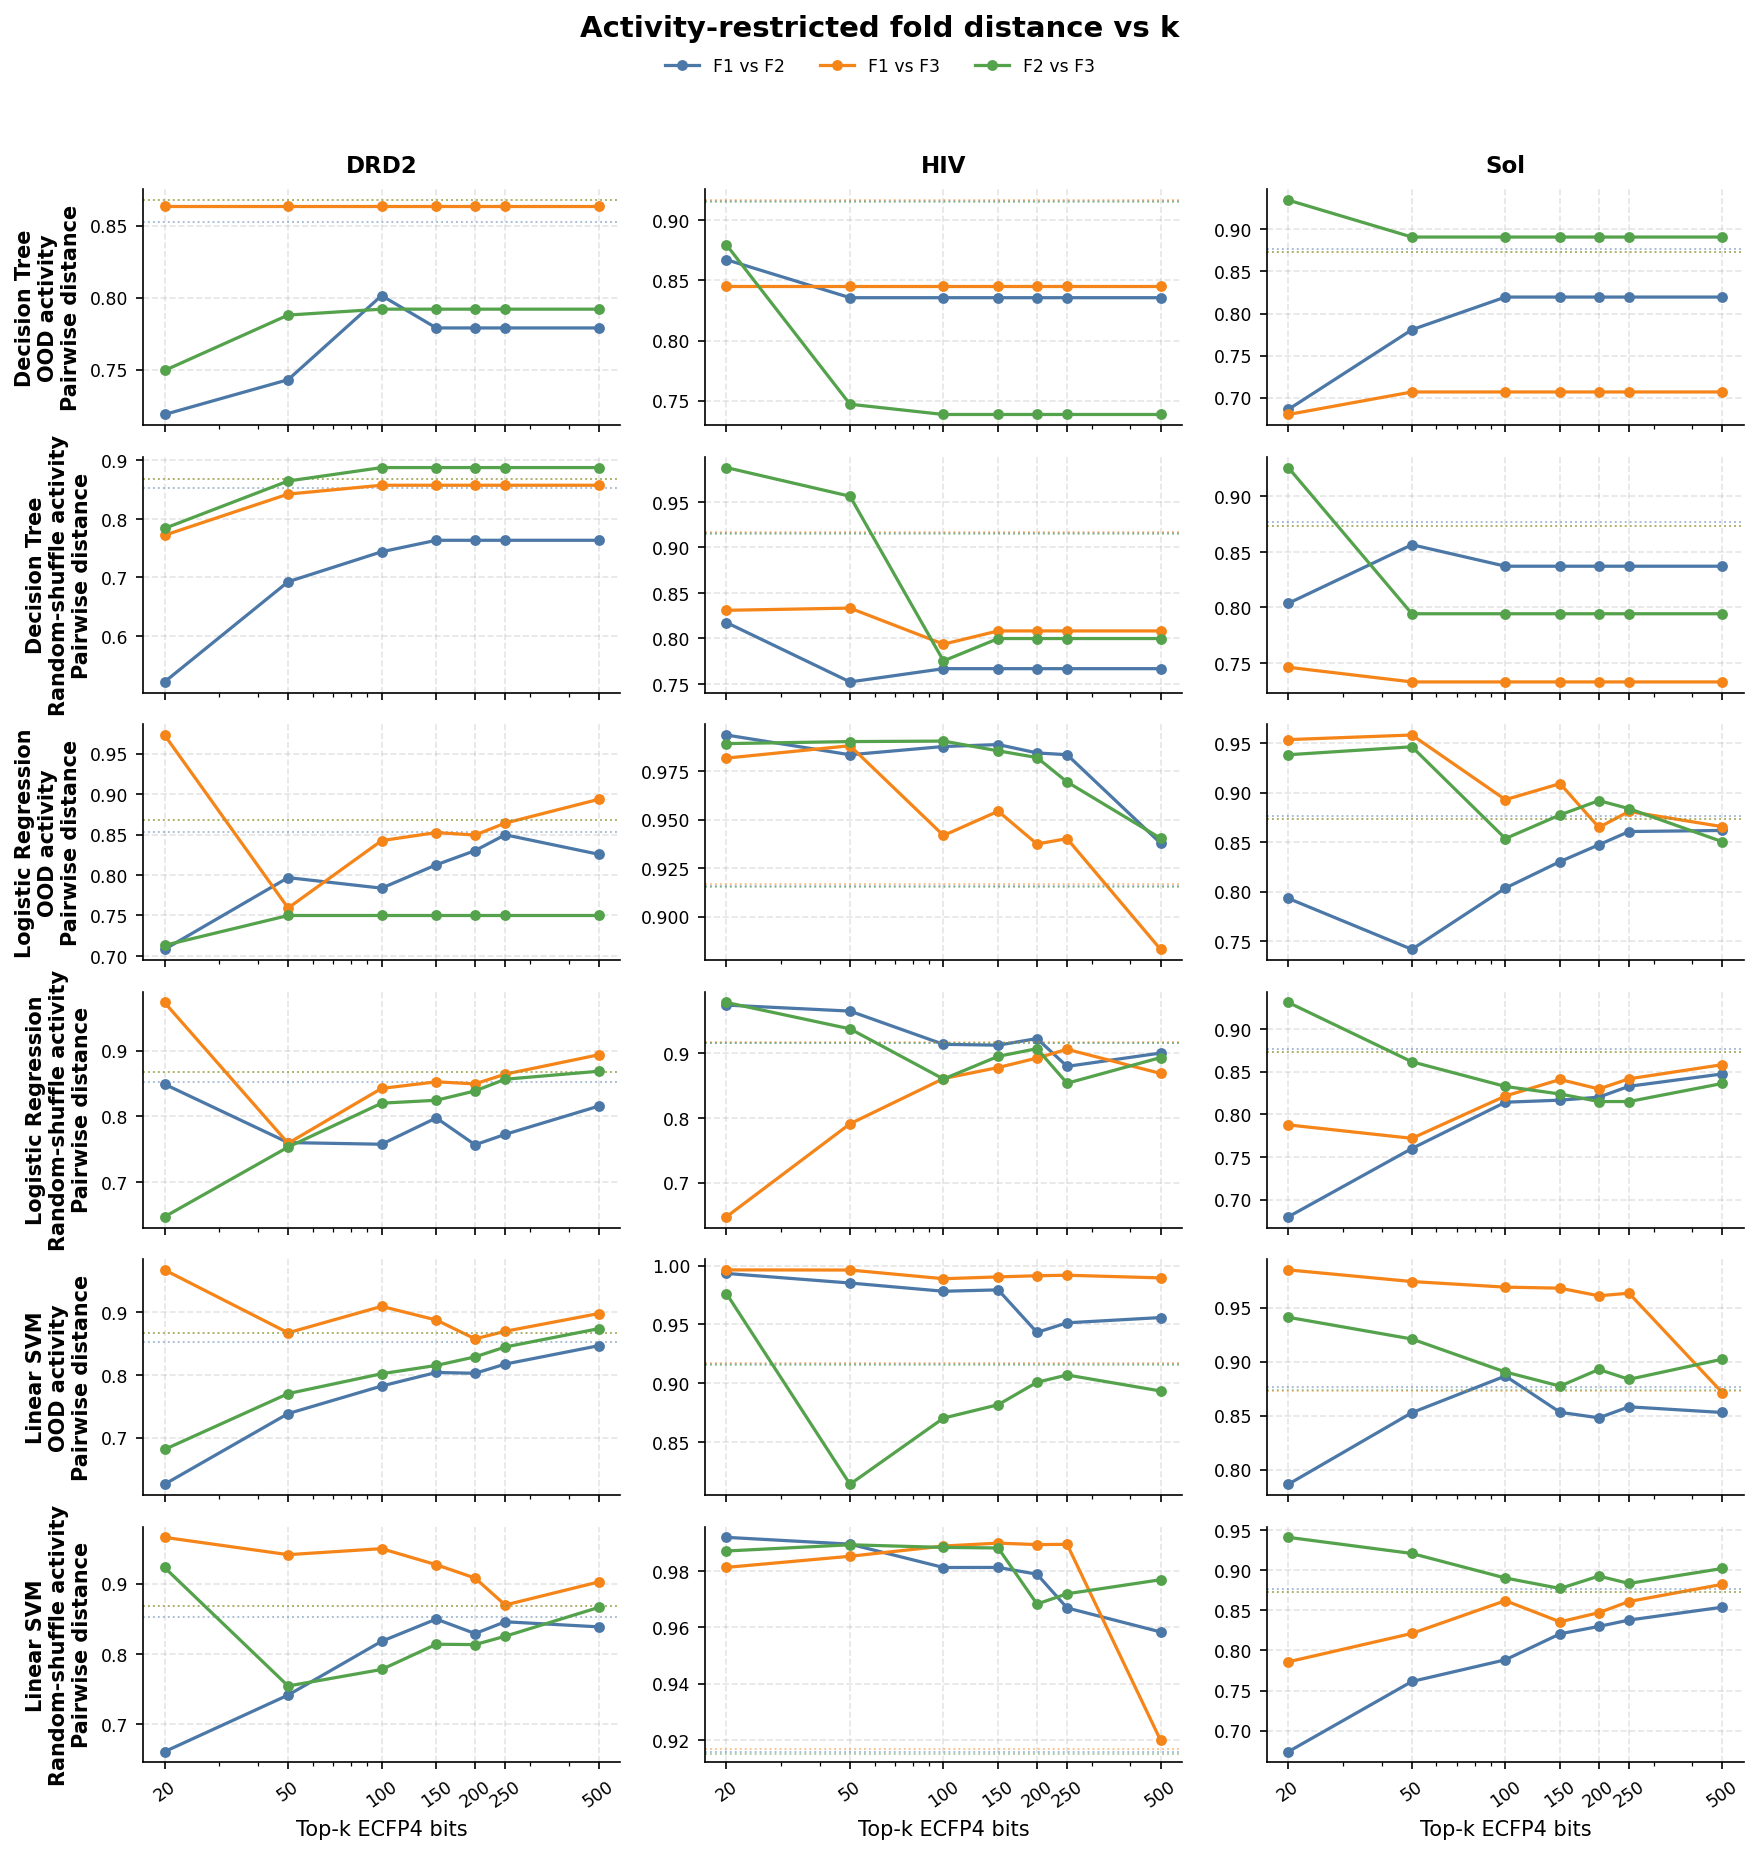

In [7]:
def fig_activity_restricted_distance_compact_grid(
    dist_all: pd.DataFrame,
):
    set_plot_style()

    row_specs = []
    for model in MODELS:
        row_specs.extend(
            [
                (model, "activity_ood", "OOD activity"),
                (model, "activity_random_shuffle", "Random-shuffle activity"),
            ]
        )

    n_rows = len(row_specs)
    n_cols = len(DATASETS)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(11.8, 12.0),
        sharex=True,
        sharey=False,
        squeeze=False,
    )

    for i, (model, src, src_label) in enumerate(row_specs):
        for j, ds in enumerate(DATASETS):
            ax = axes[i, j]

            for pair in PAIR_NAMES:
                sub = get_distance_by_k(
                    dist_all=dist_all,
                    dataset=ds,
                    model=model,
                    pair=pair,
                    bit_source=src,
                    metric="pairwise_distance",
                )

                if sub.empty:
                    continue

                ax.plot(
                    sub["k"],
                    sub["pairwise_distance"],
                    marker="o",
                    markersize=4.2,
                    lw=1.55,
                    color=PAIR_COLORS.get(pair, "C0"),
                    label=pair_label(pair),
                )

                full_ref = get_full_ecfp4_reference(
                    dist_all=dist_all,
                    dataset=ds,
                    model=model,
                    pair=pair,
                )

                if np.isfinite(full_ref):
                    ax.axhline(
                        full_ref,
                        ls=":",
                        lw=0.9,
                        color=PAIR_COLORS.get(pair, "C0"),
                        alpha=0.50,
                    )

            ax.set_xscale("log")
            ax.set_xticks(K_VALUES_PLOT)
            ax.set_xticklabels([str(k) for k in K_VALUES_PLOT], rotation=35)
            ax.grid(ls="--", alpha=0.32)

            if i == 0:
                ax.set_title(
                    DATASET_LABELS.get(ds, ds),
                    fontweight="bold",
                    pad=8,
                )

            if j == 0:
                ax.set_ylabel(
                    f"{model_label(model)}\n{src_label}\nPairwise distance",
                    fontweight="bold",
                )

            if i == n_rows - 1:
                ax.set_xlabel("Top-k ECFP4 bits")

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.suptitle(
        "Activity-restricted fold distance vs k",
        y=1.025,
        fontweight="bold",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.985])

    save_fig(
        fig,
        "activity_restricted_fold_distance_compact_grid",
    )

    plt.show()
    plt.close(fig)


fig_activity_restricted_distance_compact_grid(dist_all)

## Dataset-detection restricted fold distance

This figure measures fold-to-fold complete pairwise Tanimoto distances after projecting full ECFP4 fingerprints to top-k fold-discriminating bits.

Rows are datasets. Columns are model families. Lines are fold pairs.

The dotted horizontal lines show the corresponding full ECFP4 distance for each fold pair.

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/dataset_detection_restricted_fold_distance_grid.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/dataset_detection_restricted_fold_distance_grid.pdf


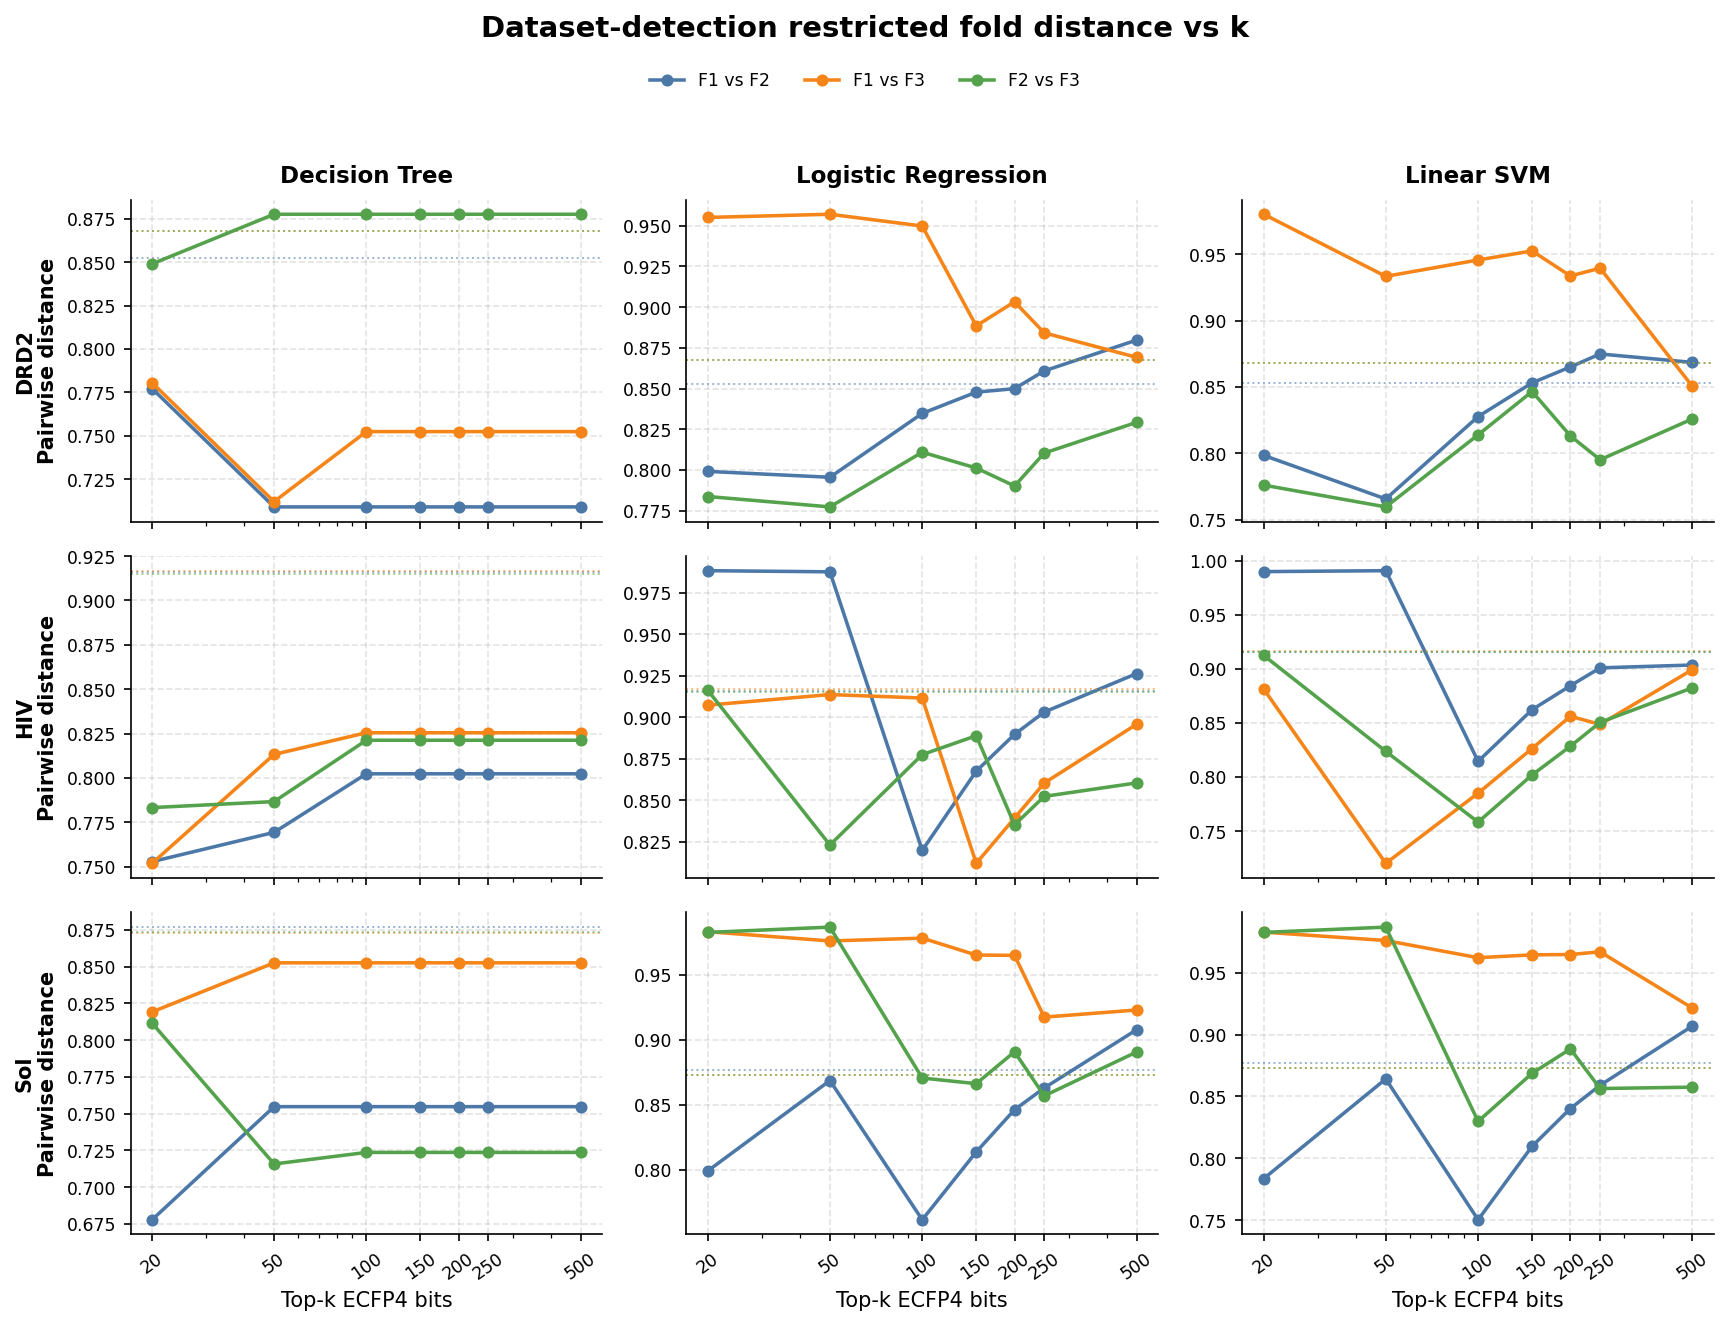

In [8]:
def fig_dataset_detection_restricted_distance_grid(
    dist_all: pd.DataFrame,
):
    set_plot_style()

    n_rows = len(DATASETS)
    n_cols = len(MODELS)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(11.6, 8.4),
        sharex=True,
        sharey=False,
        squeeze=False,
    )

    for i, ds in enumerate(DATASETS):
        for j, model in enumerate(MODELS):
            ax = axes[i, j]

            for pair in PAIR_NAMES:
                sub = get_distance_by_k(
                    dist_all=dist_all,
                    dataset=ds,
                    model=model,
                    pair=pair,
                    bit_source="dataset_detection",
                    metric="pairwise_distance",
                )

                if sub.empty:
                    continue

                ax.plot(
                    sub["k"],
                    sub["pairwise_distance"],
                    marker="o",
                    markersize=4.8,
                    lw=1.7,
                    color=PAIR_COLORS.get(pair, "C0"),
                    label=pair_label(pair),
                )

                full_ref = get_full_ecfp4_reference(
                    dist_all=dist_all,
                    dataset=ds,
                    model=model,
                    pair=pair,
                )

                if np.isfinite(full_ref):
                    ax.axhline(
                        full_ref,
                        ls=":",
                        lw=0.95,
                        color=PAIR_COLORS.get(pair, "C0"),
                        alpha=0.55,
                    )

            ax.set_xscale("log")
            ax.set_xticks(K_VALUES_PLOT)
            ax.set_xticklabels([str(k) for k in K_VALUES_PLOT], rotation=35)
            ax.grid(ls="--", alpha=0.35)

            if i == 0:
                ax.set_title(model_label(model), fontweight="bold", pad=8)

            if j == 0:
                ax.set_ylabel(
                    f"{DATASET_LABELS.get(ds, ds)}\nPairwise distance",
                    fontweight="bold",
                )

            if i == n_rows - 1:
                ax.set_xlabel("Top-k ECFP4 bits")

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.012),
    )

    fig.suptitle(
        "Dataset-detection restricted fold distance vs k",
        y=1.045,
        fontweight="bold",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.98])

    save_fig(
        fig,
        "dataset_detection_restricted_fold_distance_grid",
    )

    plt.show()
    plt.close(fig)


fig_dataset_detection_restricted_distance_grid(dist_all)

## Restricted-space coverage

This diagnostic checks the projection from full ECFP4 fingerprints to a top-k subset of selected bits.

When the fingerprint space is restricted, some molecules may become all-zero in the selected subspace. If this happens frequently, restricted-space Tanimoto distances can become unstable or hard to interpret.

The plot reports the fraction of molecules that remain valid after the projection.

The random-bit baseline shows how much coverage is expected from an arbitrary top-k subset of ECFP4 bits.

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/projection_coverage_full_ecfp4_to_topk_subset.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/projection_coverage_full_ecfp4_to_topk_subset.pdf


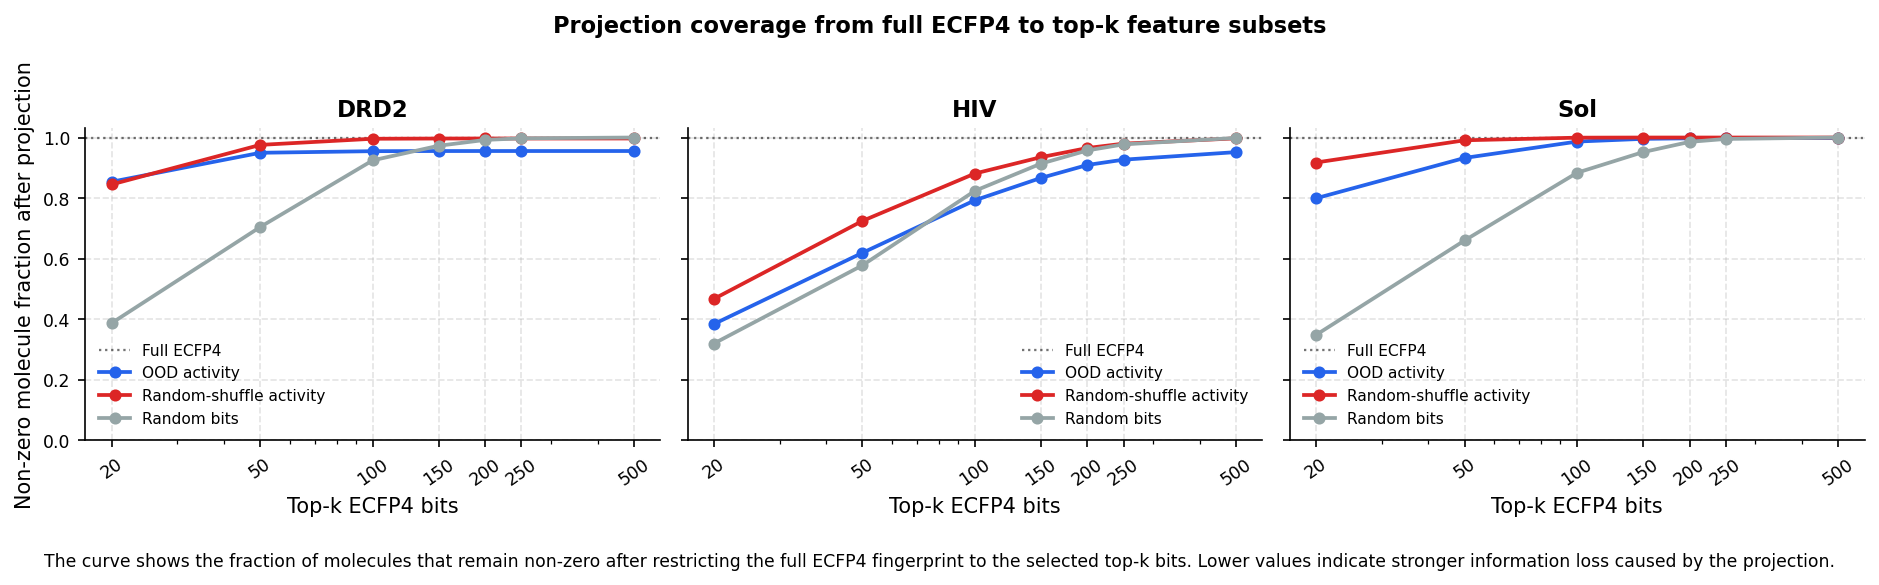

In [9]:
def fig_valid_fraction_vs_k(dist_all: pd.DataFrame):
    set_plot_style()

    projection_sources = [
        ("activity_ood", "OOD activity"),
        ("activity_random_shuffle", "Random-shuffle activity"),
        ("random_bits", "Random bits"),
    ]

    source_colors = {
        "activity_ood": "#2563EB",
        "activity_random_shuffle": "#DC2626",
        "random_bits": "#95A5A6",
    }

    datasets = [d for d in DATASETS if d in dist_all["dataset"].unique()]

    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(4.2 * len(datasets), 3.35),
        sharey=True,
        squeeze=False,
    )

    for ax, ds in zip(axes[0], datasets):
        ax.axhline(
            1.0,
            ls=":",
            lw=1.1,
            color="black",
            alpha=0.55,
            label="Full ECFP4",
        )

        for src, label in projection_sources:
            sub = dist_all[
                (dist_all["dataset"] == ds)
                & (dist_all["bit_source"] == src)
                & (dist_all["k"].isin(K_VALUES_PLOT))
            ].copy()

            if sub.empty:
                continue

            agg = (
                sub.groupby("k", as_index=False)["valid_molecule_fraction"]
                .mean()
                .sort_values("k")
            )

            ax.plot(
                agg["k"],
                agg["valid_molecule_fraction"],
                marker="o",
                markersize=4.8,
                lw=1.8,
                color=source_colors[src],
                label=label,
            )

        ax.set_xscale("log")
        ax.set_xticks(K_VALUES_PLOT)
        ax.set_xticklabels([str(k) for k in K_VALUES_PLOT], rotation=35)
        ax.set_ylim(0, 1.03)
        ax.set_xlabel("Top-k ECFP4 bits")
        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.grid(ls="--", alpha=0.35)
        ax.legend(frameon=False, fontsize=7.4)

    axes[0, 0].set_ylabel("Non-zero molecule fraction after projection")

    fig.suptitle(
        "Projection coverage from full ECFP4 to top-k feature subsets",
        fontweight="bold",
        y=1.04,
    )

    fig.text(
        0.5,
        -0.03,
        "The curve shows the fraction of molecules that remain non-zero after restricting the full ECFP4 fingerprint "
        "to the selected top-k bits. Lower values indicate stronger information loss caused by the projection.",
        ha="center",
        va="top",
        fontsize=8.3,
    )

    fig.tight_layout()

    save_fig(fig, "projection_coverage_full_ecfp4_to_topk_subset")

    plt.show()
    plt.close(fig)


fig_valid_fraction_vs_k(dist_all)

In [10]:
print("Figures saved in:")
print(FIG_ROOT)

figs = sorted(FIG_ROOT.glob("*.png"))

print(f"\nPNG figures: {len(figs)}")
for p in figs:
    print(f"  {p.name}")

Figures saved in:
/home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto

PNG figures: 3
  activity_restricted_fold_distance_compact_grid.png
  dataset_detection_restricted_fold_distance_grid.png
  projection_coverage_full_ecfp4_to_topk_subset.png
